# Probabilistic equivalence analysis

## Goal

This analysis measures whether, and by how much, SRS increases the probability that the
learner returns an automaton exactly equivalent to the target when equivalence queries
are answered probabilistically.

## Equivalence checking method

For each equivalence query and each SRS consistency check, two automata are compared on
100,000 randomly generated words, each of length at
most 100. A word on which the
automata disagree is returned as a counterexample. If no disagreement is found, the
automata are treated as equivalent. Consequently, this procedure can incorrectly accept
two automata that are not equivalent as equivalent.

## Base automaton generation

- **Random Automaton:** a randomly generated DVPA with no additional structural
  restrictions. Each transition is generated independently according to the configured
  density. An omitted transition leads to the sink state.
- **Single Entry Automaton:** a randomly generated automaton whose state set is
  partitioned into pairwise disjoint sets called modules. Local transitions do not
  leave their module. All defined transitions for a given call symbol lead to the
  same state. Thus, calls targeting a given module enter its entry point.

## Target automaton generation

- **Commutativity:** two random DVPA components are generated over disjoint parts
  of the alphabet and combined into a product automaton. If a return symbol is read
  with a stack symbol belonging to the other component, the transition is undefined
  and therefore leads to the sink state. Operations belonging to different components
  commute.
- **Cancellation:** a random DVPA is extended with a comment construct. Its opening
  symbol enters a comment state and pushes a dedicated stack symbol. The matching
  closing symbol restores the state from which the comment started, yielding the
  cancellation rule.
- **Idempotency:** a single entry automaton with two additional restrictions:

  1. Every call transition is defined.
  2. A return transition whose stack symbol denotes the current module leaves the
     current state unchanged.

## Configuration

The generator samples a new configuration for each target automaton. All ranges below
are inclusive and describe the generated target automata. The transition density is
0.8 and the accepting state density is 0.3.

- **Commutativity:** 4–30 states, 2–5 call symbols, 2–5 local symbols, 2–5 return
  symbols, and 3 stack symbols. The second component has 2–5 states.
- **Cancellation:** 10–24 states, 3–6 call symbols, 2–5 local symbols, 3–6 return
  symbols, and 3–6 stack symbols. The comment construct adds one call symbol, one
  return symbol, and one stack symbol.
- **Idempotency:** 10–24 states, 2–5 call symbols, 2–5 local symbols, 2–5 return
  symbols, and 11–26 stack symbols. The automaton has 5 modules, its stack alphabet
  contains one symbol plus one symbol for each module and call symbol combination.

## Methodology

Each data set contains 6,000 target automata generated according to the configuration
described above. Each target automaton is learned in two paired runs with the same seed:
once without SRS and once with SRS enabled.
After learning, the returned hypothesis is validated by the exact equivalence procedure.
A run is successful only when this final validation passes.

## Reported results

The plots show the percentage of runs whose final hypothesis passed exact validation,
with and without SRS.

In [1]:
from src import Plot, successRatioBy, printMeanDecrease, printAccuracy

cancellationPath = "data/probabilisticEq/cancellation_accuracy.csv"
commutativePath = "data/probabilisticEq/commutation_accuracy.csv"
idempotencyPath = "data/probabilisticEq/idempotency_accuracy.csv"


def addSuccessRatioComparison(plot, csvPath):
    plot.add(
        csvPath,
        lambda data: successRatioBy(
            data,
            xColumn="numOfStates",
            filters={"useSrs": 0},
        ),
        label="Without SRS",
    )
    plot.add(
        csvPath,
        lambda data: successRatioBy(
            data,
            xColumn="numOfStates",
            filters={"useSrs": 1},
        ),
        label="With SRS",
    )

## Commutativity

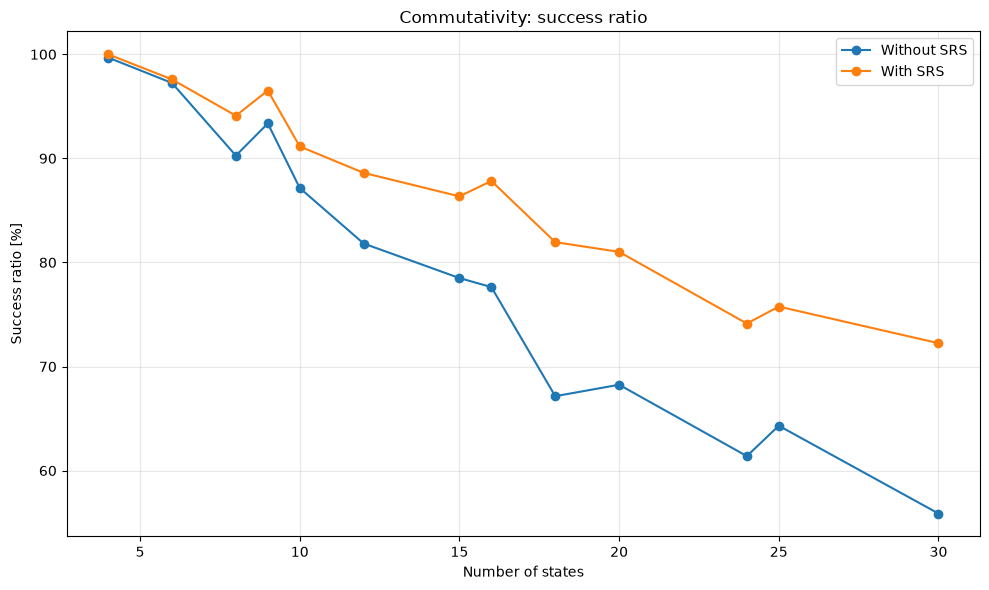

In [2]:
commutativitySuccessPlot = Plot(
    title="Commutativity: success ratio",
    xLabel="Number of states",
    yLabel="Success ratio [%]",
)
addSuccessRatioComparison(commutativitySuccessPlot, commutativePath)
commutativitySuccessPlot.draw()

In [3]:
printAccuracy(commutativePath)

Accuracy without SRS 80.78% and with SRS 88.00%  (all automata)
Average accuracy gain 8.93%  (all automata)

Accuracy without SRS 88.16% and with SRS 92.45%  (automata with at most 15 states)
Average accuracy gain 4.86%  (automata with at most 15 states)

Accuracy without SRS 60.57% and with SRS 74.07%  (automata with more than 20 states)
Average accuracy gain 22.29%  (automata with more than 20 states)


## Cancellation

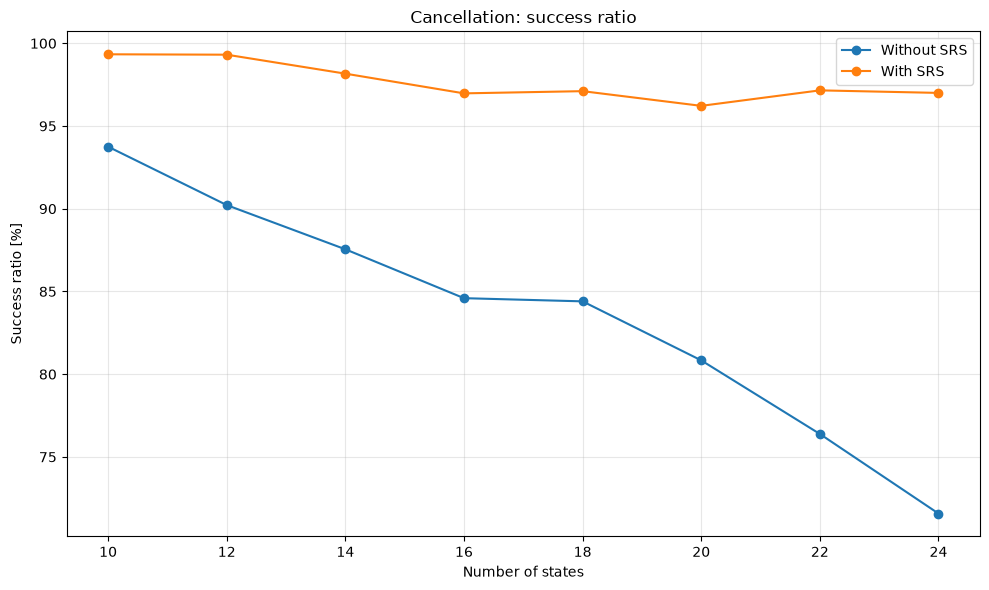

In [4]:
cancellationSuccessPlot = Plot(
    title="Cancellation: success ratio",
    xLabel="Number of states",
    yLabel="Success ratio [%]",
)
addSuccessRatioComparison(cancellationSuccessPlot, cancellationPath)
cancellationSuccessPlot.draw()

In [5]:
printAccuracy(cancellationPath)

Accuracy without SRS 83.67% and with SRS 97.65%  (all automata)
Average accuracy gain 16.71%  (all automata)

Accuracy without SRS 90.50% and with SRS 98.93%  (automata with at most 15 states)
Average accuracy gain 9.32%  (automata with at most 15 states)

Accuracy without SRS 73.88% and with SRS 97.07%  (automata with more than 20 states)
Average accuracy gain 31.40%  (automata with more than 20 states)


## Idempotency

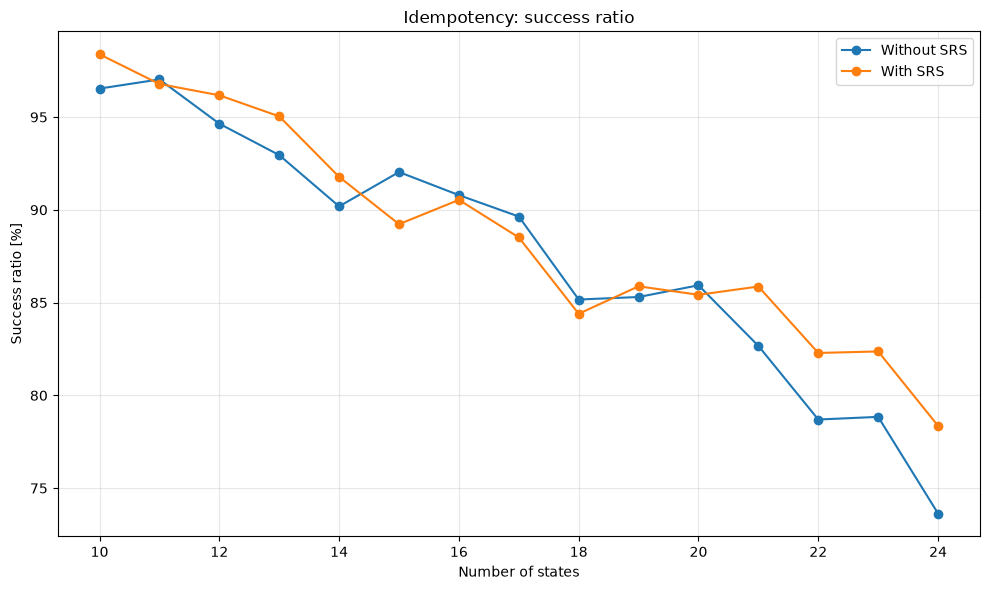

In [6]:
idempotencySuccessPlot = Plot(
    title="Idempotency: success ratio",
    xLabel="Number of states",
    yLabel="Success ratio [%]",
)
addSuccessRatioComparison(idempotencySuccessPlot, idempotencyPath)
idempotencySuccessPlot.draw()

In [7]:
printAccuracy(idempotencyPath)

Accuracy without SRS 87.63% and with SRS 88.75%  (all automata)
Average accuracy gain 1.27%  (all automata)

Accuracy without SRS 93.96% and with SRS 94.58%  (automata with at most 15 states)
Average accuracy gain 0.66%  (automata with at most 15 states)

Accuracy without SRS 78.40% and with SRS 82.16%  (automata with more than 20 states)
Average accuracy gain 4.80%  (automata with more than 20 states)
